# Loan Data — Business Problem

### The company needs to decide whether a loan application should be approved or rejected.

### Objective:
To analyze loan applicant data using Exploratory Data Analysis (EDA) and develop a Machine Learning model that predicts whether a loan application is likely to be approved or rejected based on applicant demographics, income, employment status, credit history, loan amount, and other relevant factors.

# 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

# 2. Loading and Accessing the Dataset

In [2]:
df = pd.read_csv(r"Data/Telco_Customer_Churn.csv")

# 3. Understanding the Dataset

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


In [4]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Employment_Status', 'Applicant_Income', 'Coapplicant_Income',
       'Loan_Amount', 'Loan_Term', 'Credit_History', 'Property_Area', 'Age',
       'Loan_Status'],
      dtype='object')

In [5]:
df.shape

(3192, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             3192 non-null   object 
 1   Gender              3115 non-null   object 
 2   Married             3126 non-null   object 
 3   Dependents          3192 non-null   int64  
 4   Education           3126 non-null   object 
 5   Employment_Status   3136 non-null   object 
 6   Applicant_Income    3157 non-null   float64
 7   Coapplicant_Income  3192 non-null   float64
 8   Loan_Amount         3151 non-null   float64
 9   Loan_Term           3192 non-null   int64  
 10  Credit_History      3192 non-null   int64  
 11  Property_Area       3192 non-null   object 
 12  Age                 3192 non-null   float64
 13  Loan_Status         3192 non-null   object 
dtypes: float64(4), int64(3), object(7)
memory usage: 349.3+ KB


In [7]:
df.dtypes

Loan_ID                object
Gender                 object
Married                object
Dependents              int64
Education              object
Employment_Status      object
Applicant_Income      float64
Coapplicant_Income    float64
Loan_Amount           float64
Loan_Term               int64
Credit_History          int64
Property_Area          object
Age                   float64
Loan_Status            object
dtype: object

# 4. Missing Value Analysis

In [8]:
df.isna().mean()*100

Loan_ID               0.000000
Gender                2.412281
Married               2.067669
Dependents            0.000000
Education             2.067669
Employment_Status     1.754386
Applicant_Income      1.096491
Coapplicant_Income    0.000000
Loan_Amount           1.284461
Loan_Term             0.000000
Credit_History        0.000000
Property_Area         0.000000
Age                   0.000000
Loan_Status           0.000000
dtype: float64

In [9]:
df[df.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.duplicated().sum()

np.int64(0)

# 5. Data Cleaning and Preprocessing

In [11]:
df.isna().mean()*100

Loan_ID               0.000000
Gender                2.412281
Married               2.067669
Dependents            0.000000
Education             2.067669
Employment_Status     1.754386
Applicant_Income      1.096491
Coapplicant_Income    0.000000
Loan_Amount           1.284461
Loan_Term             0.000000
Credit_History        0.000000
Property_Area         0.000000
Age                   0.000000
Loan_Status           0.000000
dtype: float64

In [12]:
df=df.dropna()

In [13]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Employment_Status     0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Term             0
Credit_History        0
Property_Area         0
Age                   0
Loan_Status           0
dtype: int64

In [14]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


# 6. Exploratory Data Analysis

* Univariate Analysis
* Bivariate Analysis
* Multivariate Analysis
* Distribution Analysis
* Correlation Analysis

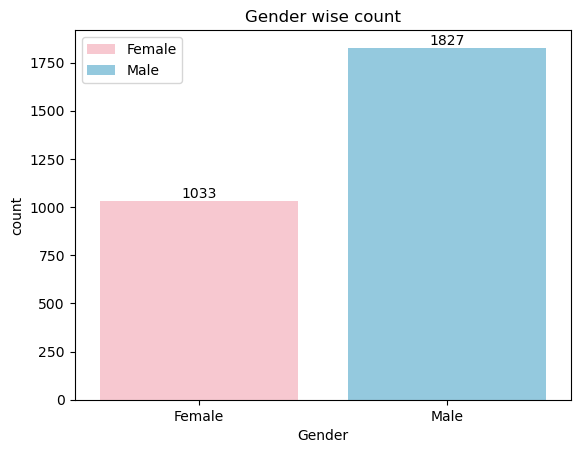

In [15]:
ax = sns.countplot(data=df,x='Gender',palette={'Male':'skyblue','Female':'pink'})
plt.title('Gender wise count')
plt.legend(['Female','Male'])
for container in ax.containers:
    ax.bar_label(container)

Insights:
* Male are 1827.
* Female are 1033.
* There are more Male members compare to Female.

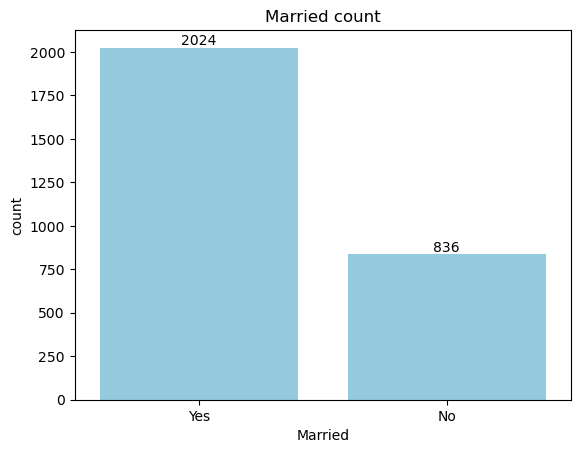

In [16]:
ax = sns.countplot(data=df,x='Married',color='skyblue')
plt.title('Married count')
for container in ax.containers :
    ax.bar_label(container)

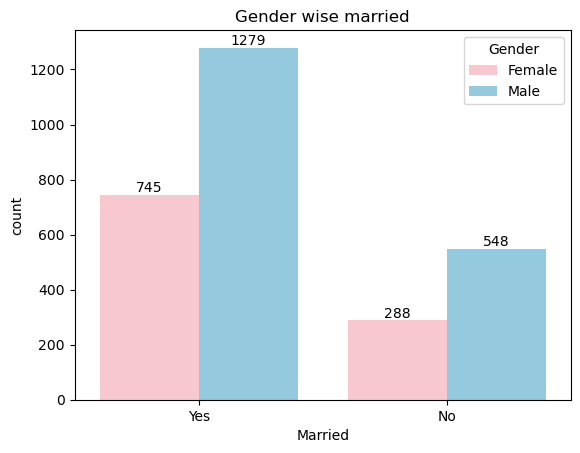

In [17]:
ax = sns.countplot(data=df,x='Married',hue='Gender',palette={'Male':'skyblue','Female':'pink'})
plt.title('Gender wise married')
for container in ax.containers :
    ax.bar_label(container)

Insights:
* There are more Married members in data.
* Male applicants are more in married count.

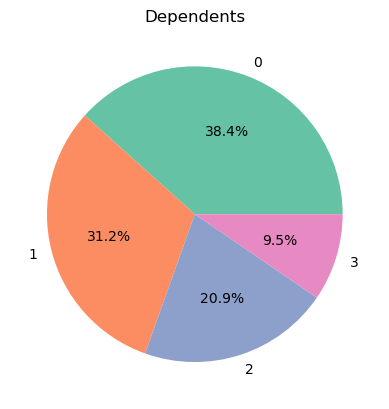

In [18]:
Dependents=df['Dependents'].value_counts()
plt.pie(Dependents,labels=Dependents.index,autopct='%1.1f%%',colors=sns.color_palette('Set2'))
plt.title('Dependents')
plt.show()

Insights:
* In Dependents there is 0 has 38.4 % .
* And least Dependents is 3 it has 9.5 % .

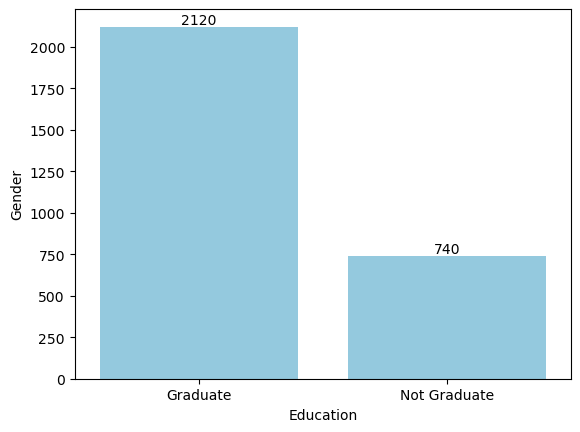

In [19]:
ax = sns.barplot(df.groupby('Education')['Gender'].count(),color='skyblue')
for container in ax.containers :
    ax.bar_label(container)

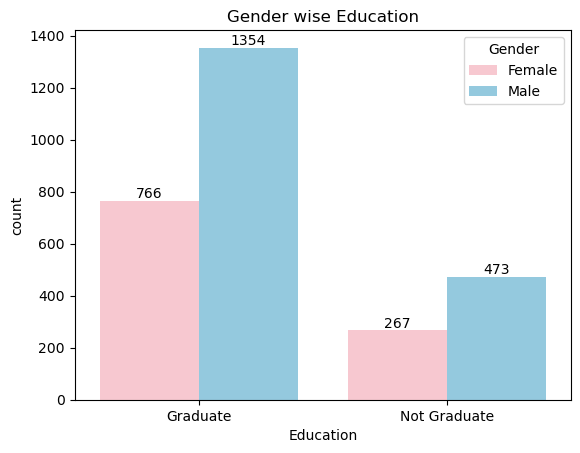

In [20]:
ax = sns.countplot(data=df,x='Education',hue='Gender',palette={'Male':'skyblue','Female':'pink'})
plt.title('Gender wise Education')
for container in ax.containers :
    ax.bar_label(container)

Insights:
* Education wise Graduate is more compare to not Graduate.
* Graduates are 3 times more compare to not Graduated.
* Male applicants are more in Graduated.

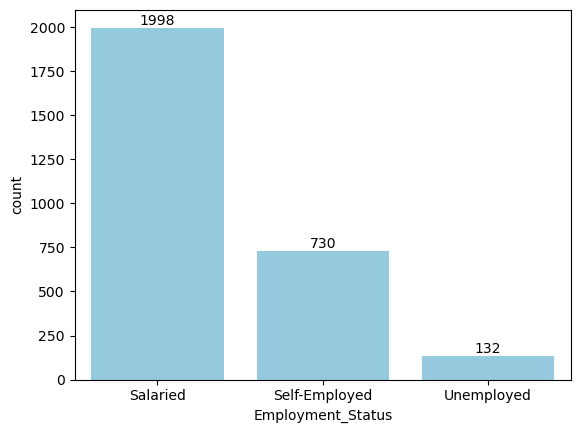

In [21]:
ax = sns.countplot(data=df,x='Employment_Status',color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

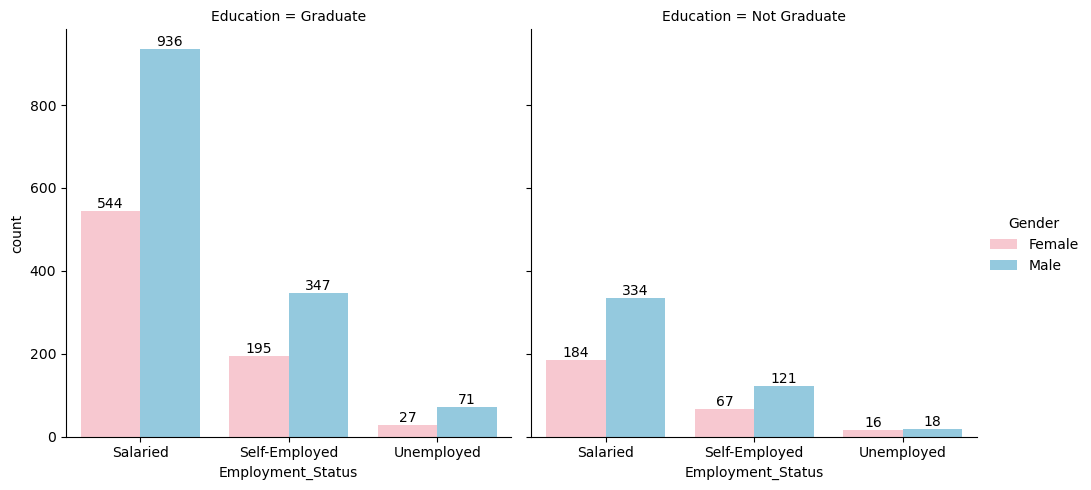

In [22]:
g = sns.catplot(data=df,x='Employment_Status',hue='Gender',col='Education',kind='count',palette={'Male':'skyblue','Female':'pink'})
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

Insights:
* Employement_status wise Salaried Employes are more.
* Self-employed is more compare to unemployed.
* Graduate wise Salaried applicants are more.
* not-Graduate wise also Salaried applicants are more.

Text(0.5, 1.0, 'Applicant_Income distribution ')

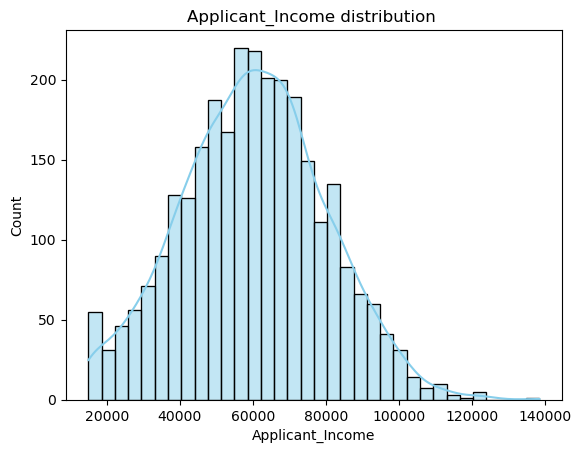

In [23]:
sns.histplot(data=df,x='Applicant_Income',color='skyblue',kde=True)
plt.title('Applicant_Income distribution ')

Insights:
* More Applicant_Income has in between 40k to 80k.
* in between 80k to 140k it reducing.

Text(0.5, 1.0, 'Coapplicant_Income distribution ')

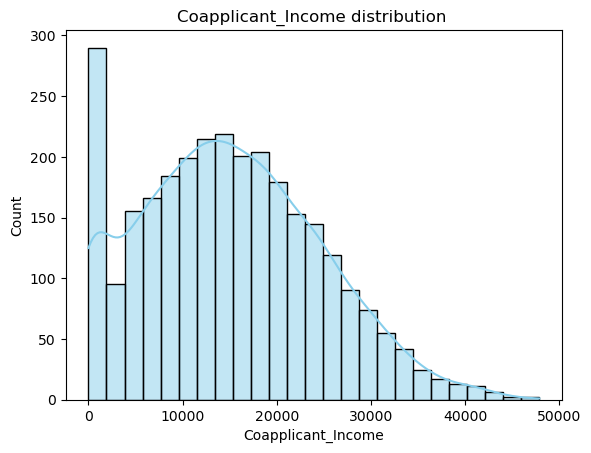

In [24]:
sns.histplot(data=df,x='Coapplicant_Income',color='skyblue',kde=True)
plt.title('Coapplicant_Income distribution ')

Insights:
* More Coapplicant_Income are between 10k to 25k.
* Coapplicant_Income are reducing from 25k .

Text(0.5, 1.0, 'Loan_Amount distribution')

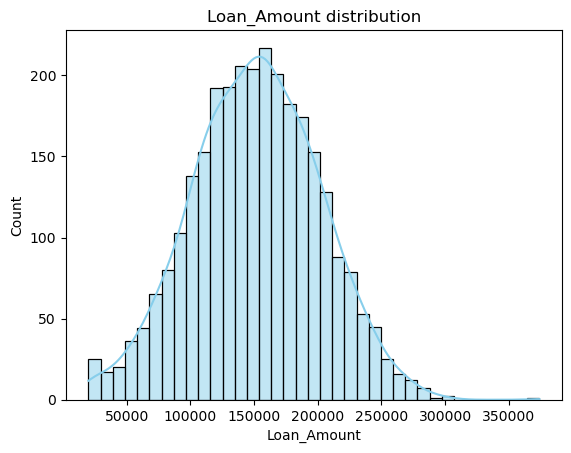

In [25]:
sns.histplot(data=df,x='Loan_Amount',color='skyblue',kde=True)
plt.title('Loan_Amount distribution')

Insights:
* Loan_Amount more applicants are taking in between 1 lakh to 2 lakh.
* There is lest number of applicants taking beyound 2.5 lakhs.

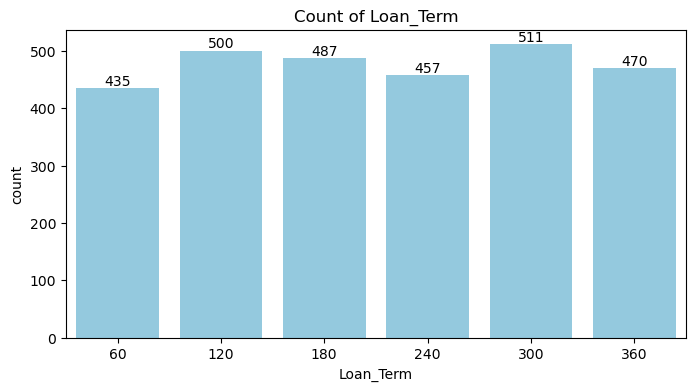

In [26]:
plt.figure(figsize=(8,4))
ax = sns.countplot(data=df,x='Loan_Term',color='skyblue')
plt.title('Count of Loan_Term')
for container in ax.containers:
    ax.bar_label(container)

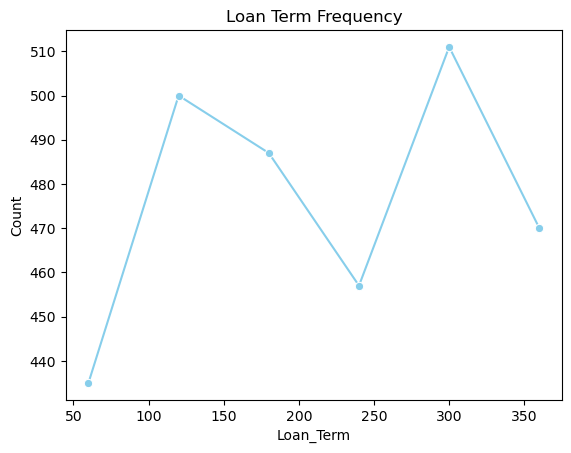

In [27]:
loan_term_counts = df.groupby('Loan_Term').size().reset_index(name='Count')

sns.lineplot(data=loan_term_counts, x='Loan_Term', y='Count', marker='o',color='skyblue')
plt.ylabel('Count')
plt.title('Loan Term Frequency')
plt.show()

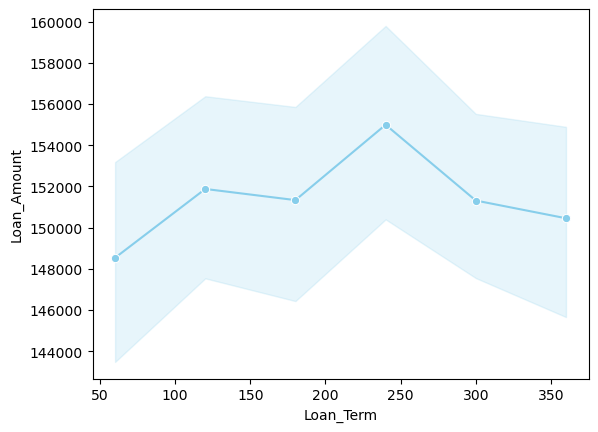

In [28]:
sns.lineplot(data=df, x='Loan_Term', y='Loan_Amount', marker='o',color='skyblue')
plt.show()

Insights:
* More number of applicants are selecting 300 months as lone term.
* least is 60 months in loan term.
* increase in Loan_amount increase in Loan_Term.

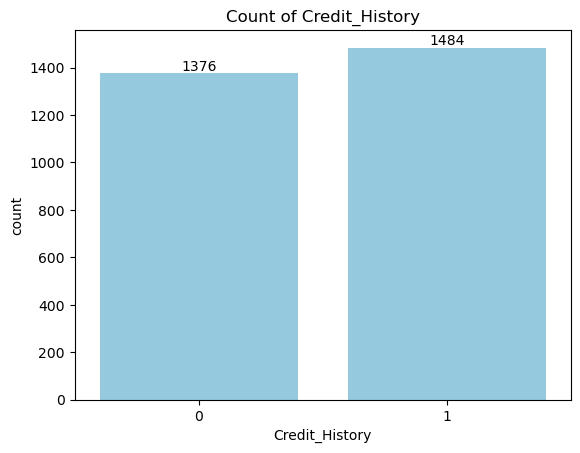

In [29]:
ax = sns.countplot(data=df,x='Credit_History',color='skyblue')
plt.title('Count of Credit_History')
for container in ax.containers:
    ax.bar_label(container)

Insights:
* Credit_History 1 has 1484.
* Credit_History 0 has 1376.

Text(0.5, 1.0, 'Property wise count')

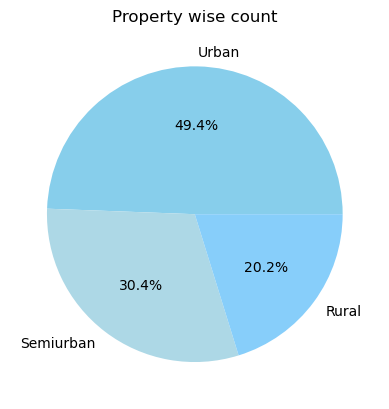

In [30]:
Property=df['Property_Area'].value_counts()
plt.pie(Property,labels=Property.index,autopct="%1.1f%%",colors=['skyblue','lightblue','lightskyblue'])
plt.title('Property wise count')

Insights:
* Property wise Urban members are more and it has 50 % of total applicants.
* Semiurban take 2nd place in property wise. 

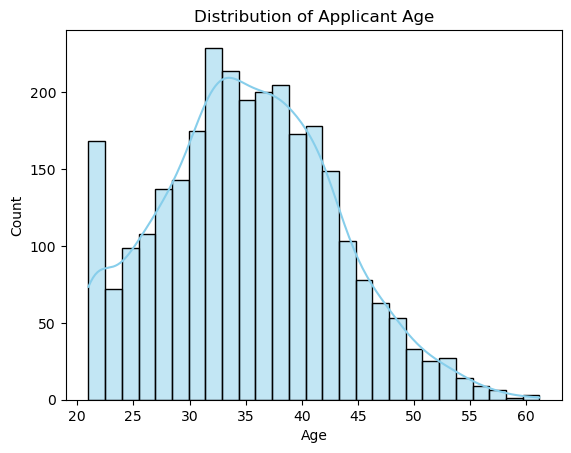

In [31]:
sns.histplot(data=df, x='Age', kde=True,color='skyblue')
plt.title('Distribution of Applicant Age')
plt.show()

Insights:
* There are more applicants of age is in between 30 to 45.
* less applicants age beyound 50.

In [32]:
df.groupby('Loan_Status').size().reset_index(name='count')

,Loan_Status,count
0,Approved,1437
1,Rejected,1423


Text(0.5, 1.0, 'Loan_Status')

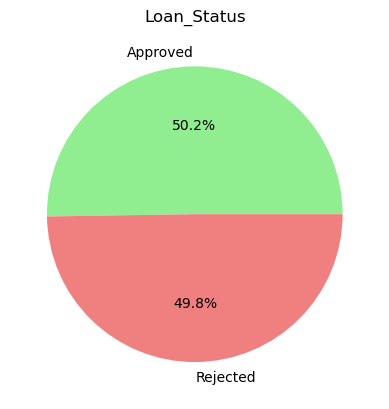

In [33]:
Loan_Status = df.groupby('Loan_Status').size().reset_index(name='count')
plt.pie(x=Loan_Status['count'],labels=Loan_Status['Loan_Status'],colors=['lightgreen','lightcoral'],autopct='%1.1f%%')
plt.title('Loan_Status')

Insights:
* Approved and Rejected are same both are sharing 50% .

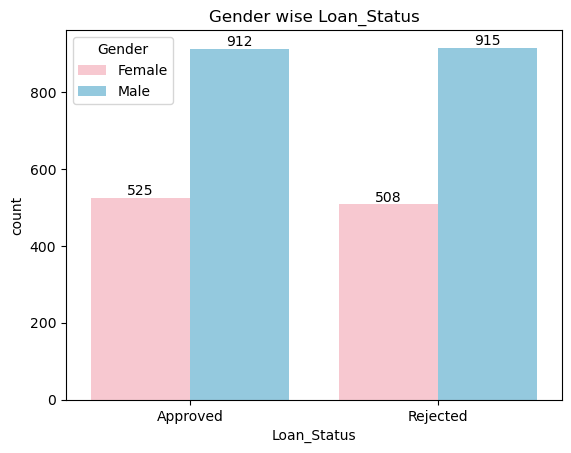

In [34]:
ax = sns.countplot(data=df,x='Loan_Status',hue='Gender',palette={'Male':'skyblue','Female':'pink'})
plt.title('Gender wise Loan_Status')
for container in ax.containers:
    ax.bar_label(container)

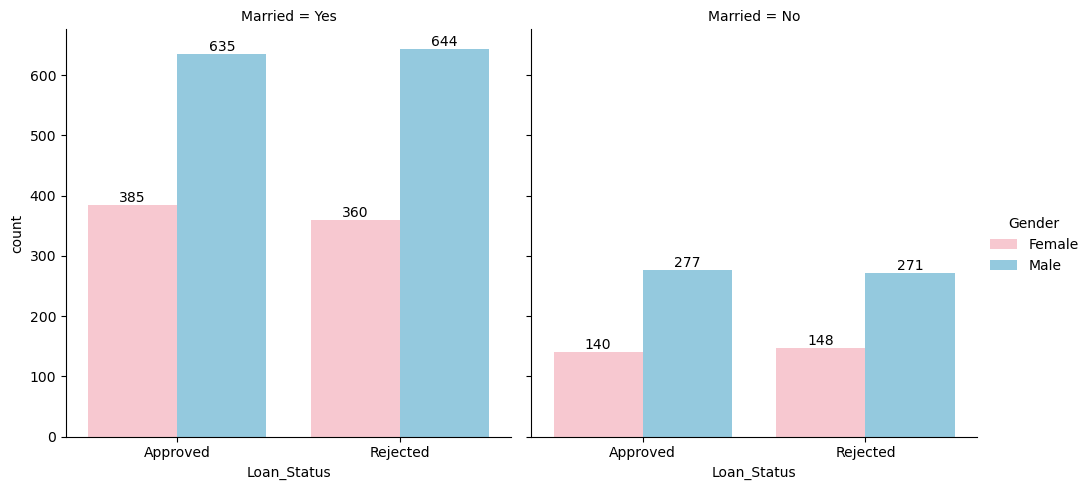

In [35]:
g = sns.catplot(data=df,x='Loan_Status',col='Married',kind='count',hue='Gender',palette={'Male':'skyblue','Female':'pink'})
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

insights:
* There is no much difference loan status in applicant where married or not married.

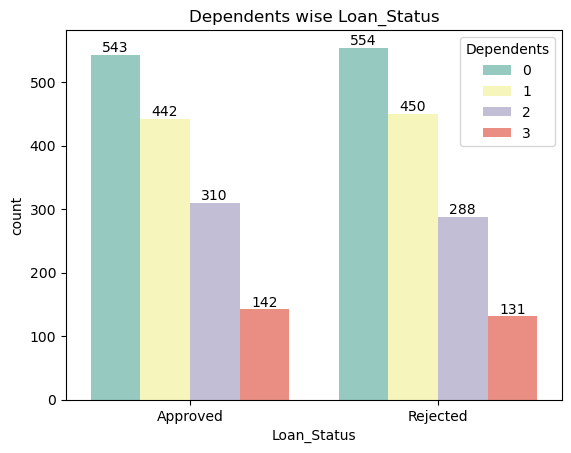

In [36]:
ax = sns.countplot(data=df,x='Loan_Status',hue='Dependents',palette=sns.color_palette('Set3'))
plt.title('Dependents wise Loan_Status')
for container in ax.containers:
    ax.bar_label(container)

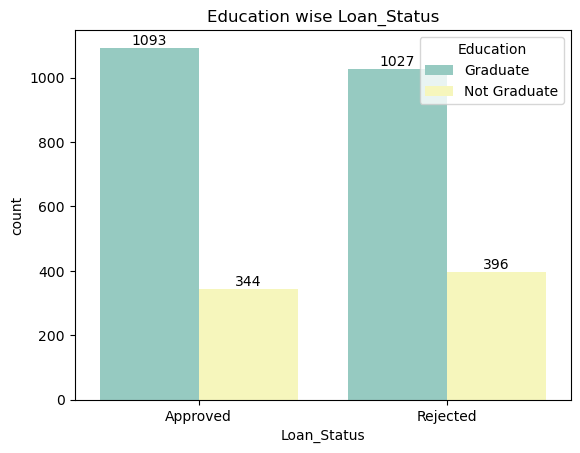

In [37]:
ax = sns.countplot(data=df,x='Loan_Status',hue='Education',palette=sns.color_palette('Set3'))
plt.title('Education wise Loan_Status')
for container in ax.containers:
    ax.bar_label(container)

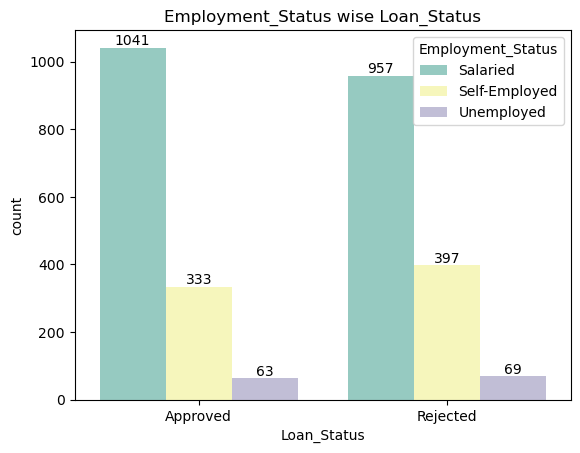

In [38]:
ax = sns.countplot(data=df,x='Loan_Status',hue='Employment_Status',palette=sns.color_palette('Set3'))
plt.title('Employment_Status wise Loan_Status')
for container in ax.containers:
    ax.bar_label(container)

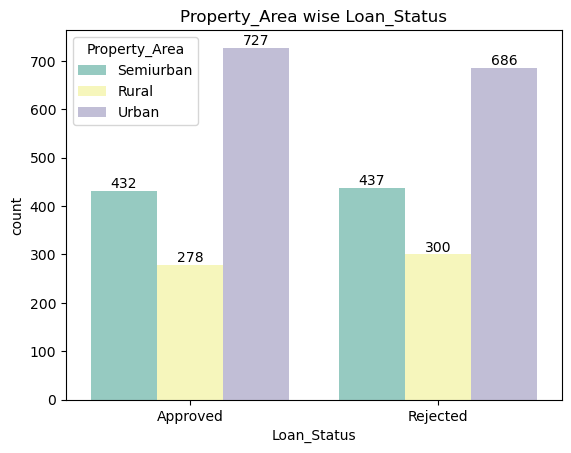

In [39]:
ax = sns.countplot(data=df,x='Loan_Status',hue='Property_Area',palette=sns.color_palette('Set3'))
plt.title('Property_Area wise Loan_Status')
for container in ax.containers:
    ax.bar_label(container)

Insights:
* The analysis does not show a significant or consistent relationship between these individual applicant characteristics and loan approval status.

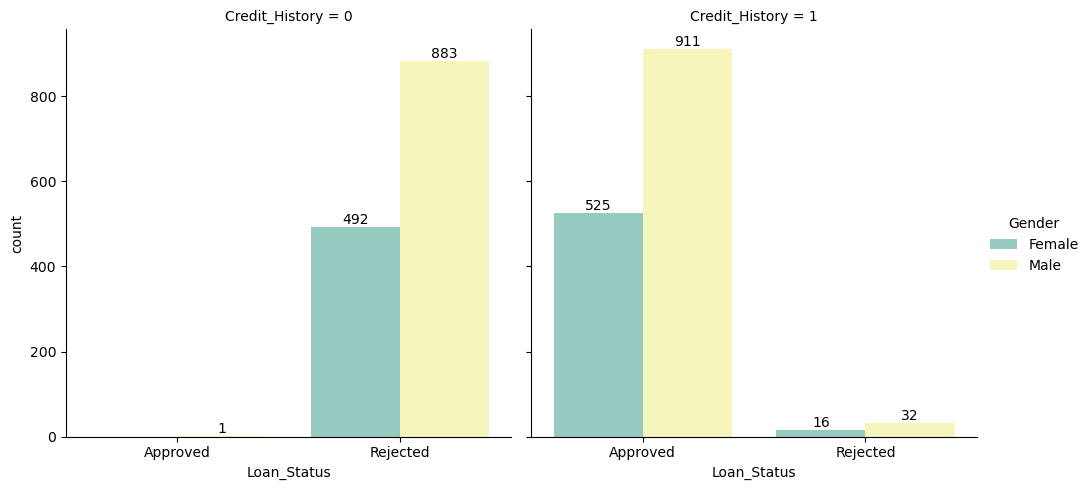

In [40]:
g = sns.catplot(data=df,x='Loan_Status',hue='Gender',col='Credit_History',kind='count',palette=sns.color_palette('Set3'))

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

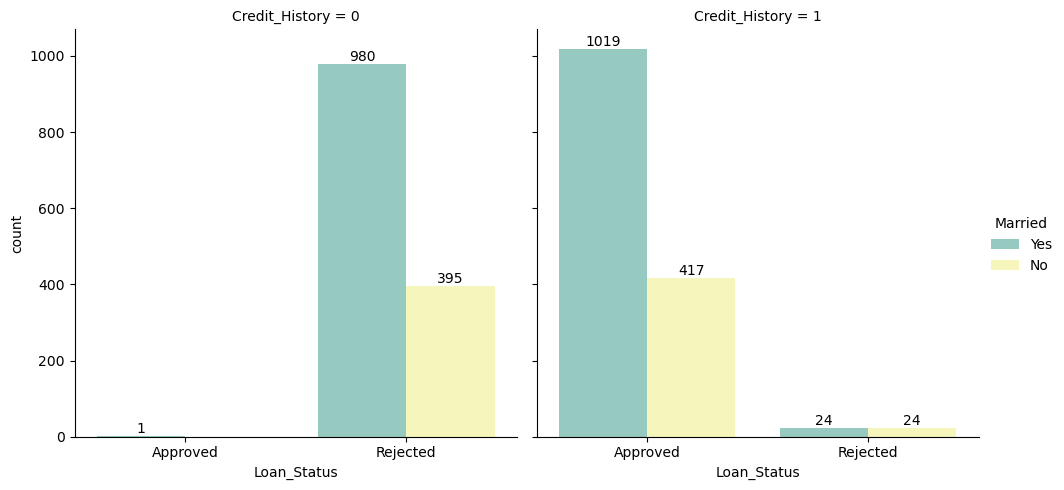

In [41]:
g = sns.catplot(data=df,x='Loan_Status',hue='Married',col='Credit_History',kind='count',palette=sns.color_palette('Set3'))

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

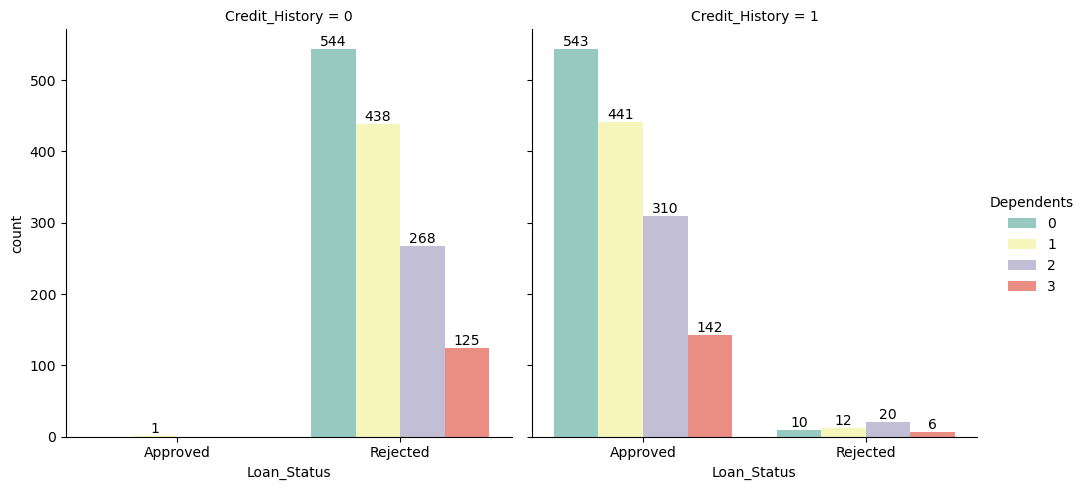

In [42]:
g = sns.catplot(data=df,x='Loan_Status',hue='Dependents',col='Credit_History',kind='count',palette=sns.color_palette('Set3'))

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

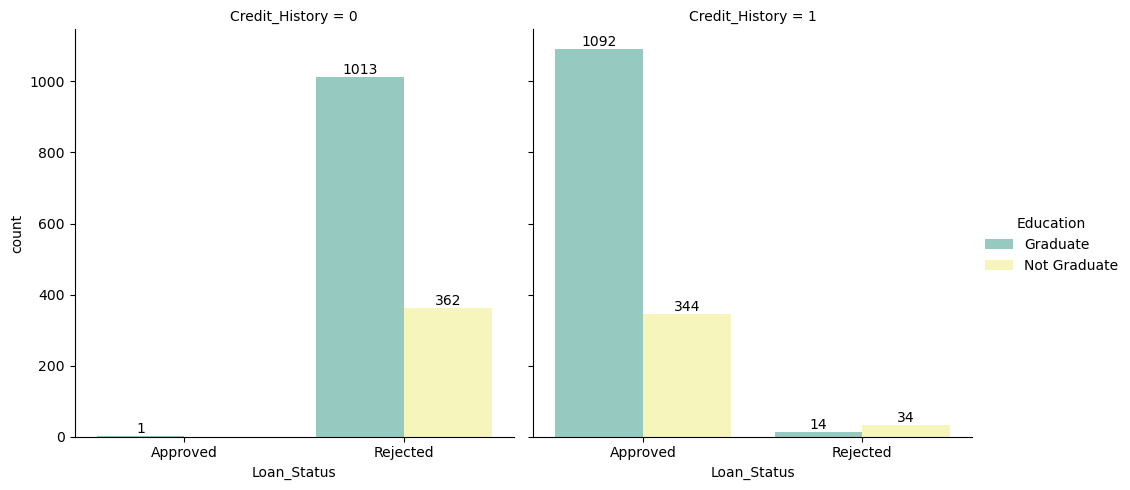

In [43]:
g = sns.catplot(data=df,x='Loan_Status',hue='Education',col='Credit_History',kind='count',palette=sns.color_palette('Set3'))

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

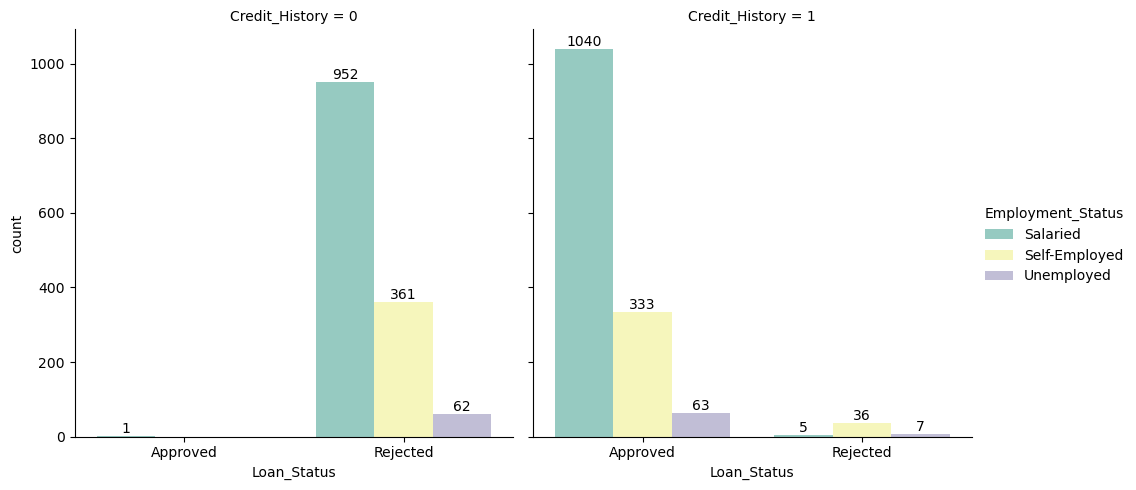

In [44]:
g = sns.catplot(data=df,x='Loan_Status',hue='Employment_Status',col='Credit_History',kind='count',palette=sns.color_palette('Set3'))

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

Insights:

* Credit history shows a significant relationship with loan status, indicating that applicants credit history are more likely to have their loans approved.

<Axes: xlabel='Loan_Status', ylabel='Applicant_Income'>

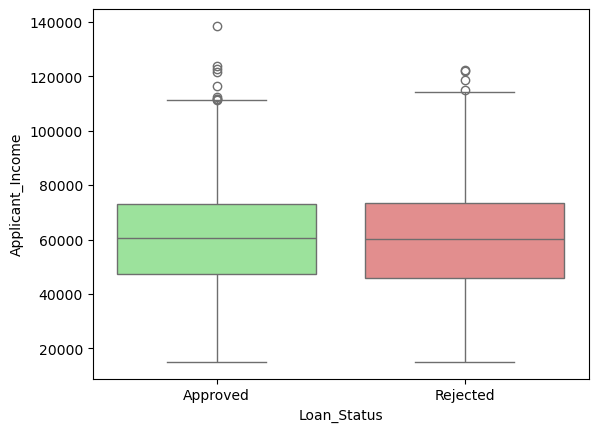

In [45]:
sns.boxplot(data=df, x='Loan_Status', y='Applicant_Income',palette={'Approved':'lightgreen','Rejected':'lightcoral'})

<Axes: xlabel='Loan_Status', ylabel='Coapplicant_Income'>

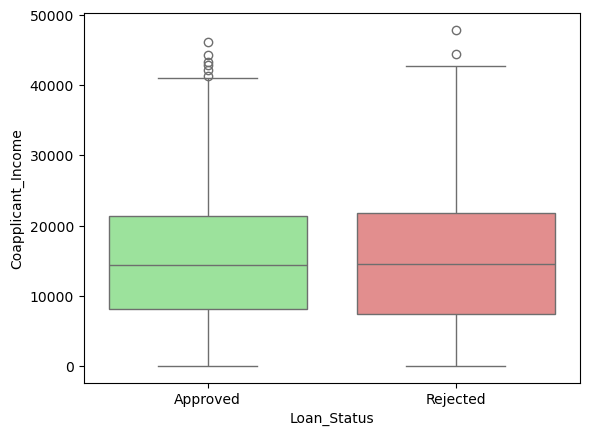

In [46]:
sns.boxplot(data=df, x='Loan_Status', y='Coapplicant_Income',palette={'Approved':'lightgreen','Rejected':'lightcoral'})

<Axes: xlabel='Loan_Status', ylabel='Loan_Amount'>

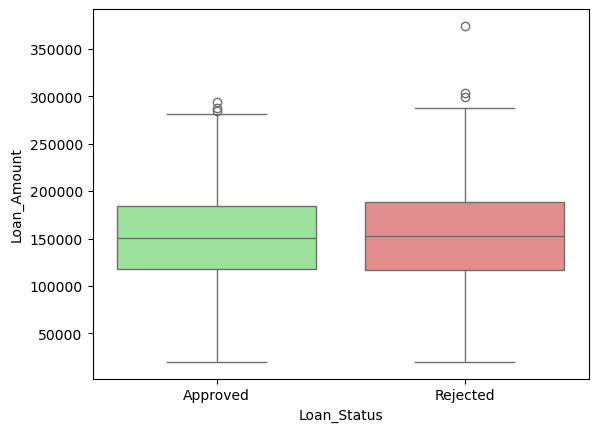

In [47]:
sns.boxplot(data=df, x='Loan_Status', y='Loan_Amount',palette={'Approved':'lightgreen','Rejected':'lightcoral'})

Insights:
* Loan_Status does not shows an significant relationship with Applicant_Income , Coapplicant_Income , Loan_Amount.

Text(0.5, 1.0, 'Applicant Income vs Loan Amount')

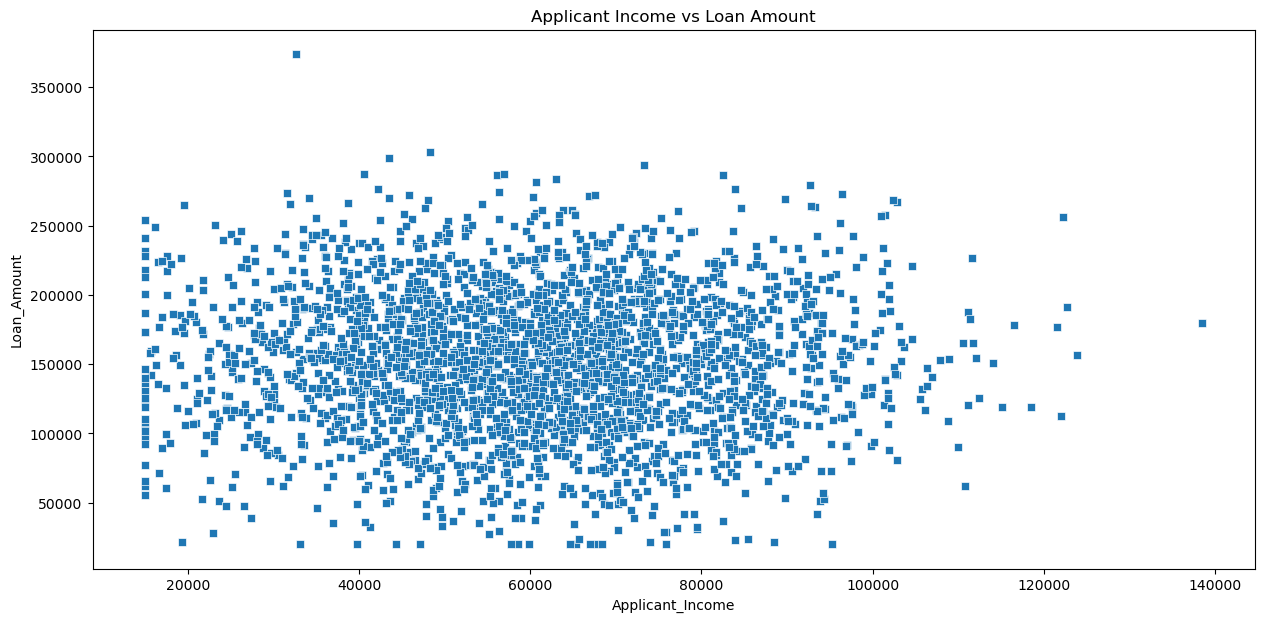

In [48]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df,x='Applicant_Income',y='Loan_Amount',marker='s')
plt.title('Applicant Income vs Loan Amount')

Text(0.5, 1.0, 'Coapplicant_Income vs Loan Amount')

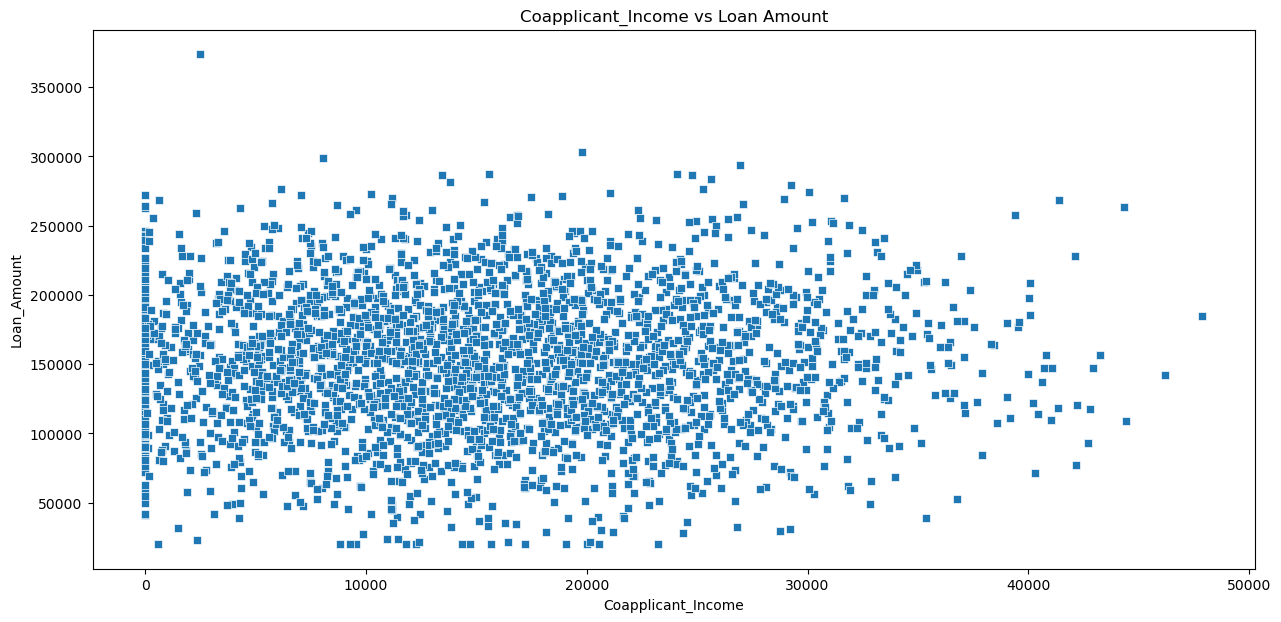

In [49]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df,x='Coapplicant_Income',y='Loan_Amount',marker='s')
plt.title('Coapplicant_Income vs Loan Amount')

Text(0.5, 1.0, 'Approve & Rejected')

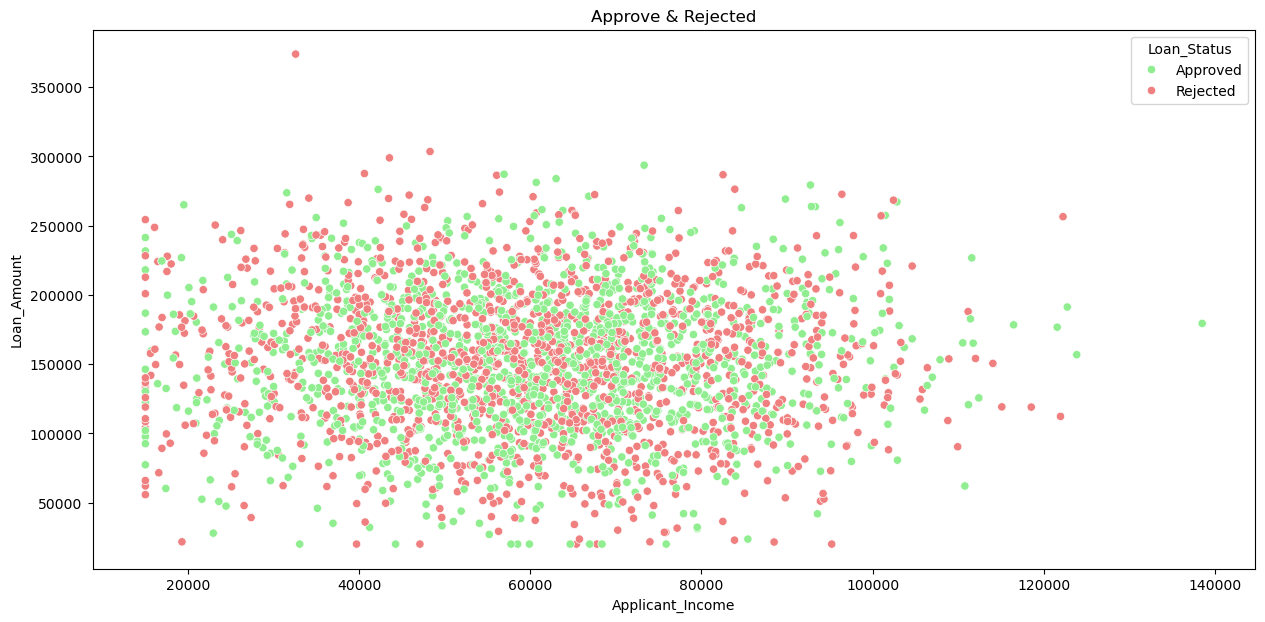

In [50]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df,x='Applicant_Income',y='Loan_Amount',hue='Loan_Status',palette={'Approved':'lightgreen','Rejected':'lightcoral'})
plt.title('Approve & Rejected')

Insights:
* mostly Applicant_Income is in between 40k to 80k whose loan amout above 100k to 230k.
* mostly Coapplicant_Income is in between 5k to 30k.

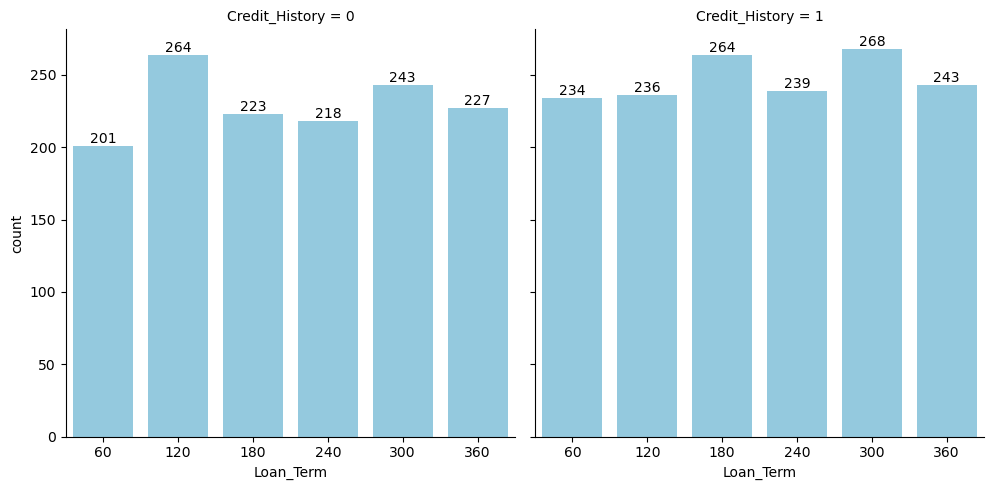

In [51]:
g = sns.catplot(data=df,x='Loan_Term',col='Credit_History',kind='count',color='skyblue')
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

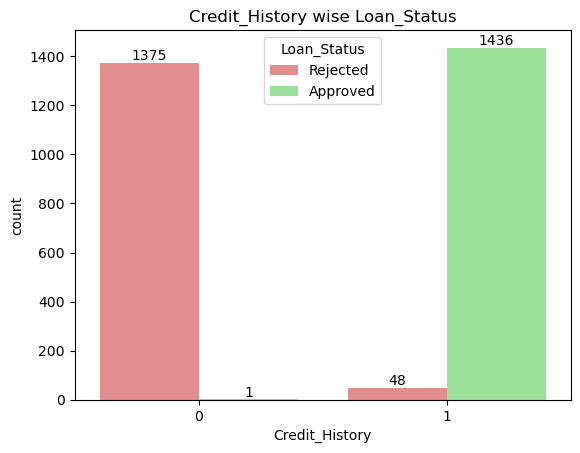

In [52]:
ax = sns.countplot(data=df,x='Credit_History',hue='Loan_Status',palette={'Approved':'lightgreen','Rejected':'lightcoral'})
plt.title('Credit_History wise Loan_Status')
for container in ax.containers:
    ax.bar_label(container)

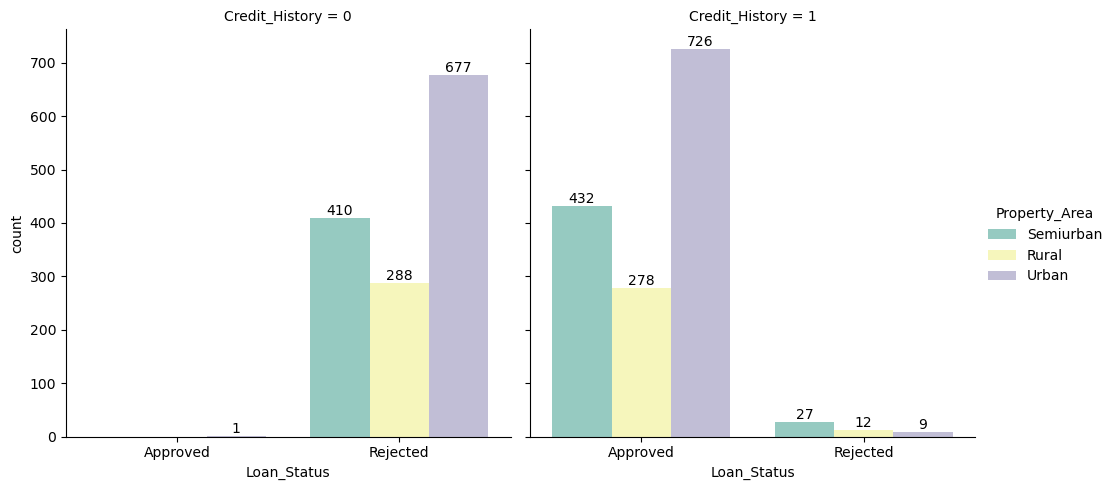

In [53]:
g = sns.catplot(data=df,x='Loan_Status',hue='Property_Area',col='Credit_History',kind='count',palette=sns.color_palette('Set3'))
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

Insights:
* Credit History plays a key role in determining Loan Status, with applicants having 1 credit history generally showing a higher likelihood of loan approval

In [54]:
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved


In [55]:
df_clean=df.drop(columns=['Loan_ID'])

In [56]:
df_dummies = pd.get_dummies(df_clean,drop_first=True)

In [57]:
df_dummies.head(2)

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Age,Gender_Male,Married_Yes,Education_Not Graduate,Employment_Status_Self-Employed,Employment_Status_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Rejected
0,3,34473.911669,13914.721574,240732.458366,180,1,40.084028,False,True,False,False,False,True,False,False
1,1,59718.020682,18720.814787,122547.278442,180,1,47.243644,False,True,False,True,False,True,False,False


<Axes: >

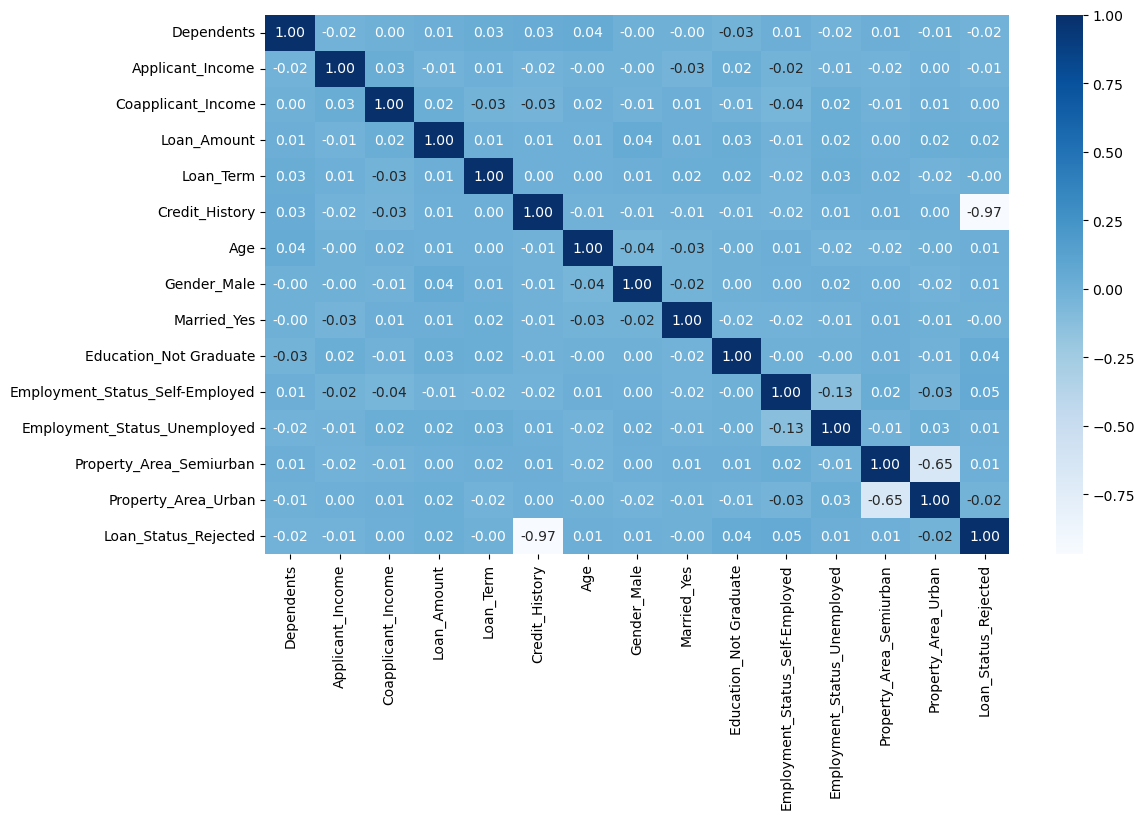

In [58]:
plt.figure(figsize=(12,7))
sns.heatmap(df_dummies.corr(),annot=True,cmap='Blues',fmt='.2f')

Insights:
* Credit_History shows a very strong positive correlation with Loan_Status, with a correlation coefficient of - 0.97.
* Lenders should give greater importance to credit history when assessing loan applications, as it can be a strong indicator of loan approval and rejection.

# 7. Machine Learning Model Development

## Importing Required Libraries for Machine Learning

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [60]:
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved


## Feature and Target Selection

In [61]:
x = df.drop(columns=['Loan_ID','Loan_Status'],axis=1)

In [62]:
y = df['Loan_Status']

In [63]:
x.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Employment_Status',
       'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term',
       'Credit_History', 'Property_Area', 'Age'],
      dtype='object')

In [64]:
y

0       Approved
1       Approved
2       Approved
3       Approved
4       Approved
          ...   
3186    Rejected
3187    Approved
3188    Approved
3189    Approved
3190    Approved
Name: Loan_Status, Length: 2860, dtype: object

## Splitting Data into Training and Testing Sets

In [65]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Manual Feature Segmentation for Preprocessing

In [66]:
#Separating Numerical and Categorical Features
cat_col = x.select_dtypes(include='object').columns.tolist()
num_col = x.select_dtypes(exclude='object').columns.tolist()

In [67]:
cat_col

['Gender', 'Married', 'Education', 'Employment_Status', 'Property_Area']

In [68]:
num_col

['Dependents',
 'Applicant_Income',
 'Coapplicant_Income',
 'Loan_Amount',
 'Loan_Term',
 'Credit_History',
 'Age']

## Applying ColumnTransformer for Feature Preprocessing

In [69]:
preprosser = ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore'),cat_col),('num',StandardScaler(),num_col)])

## Feature Encoding and Scaling

In [70]:
x_train = preprosser.fit_transform(x_train)

In [71]:
x_test = preprosser.transform(x_test)

## Building the Random Forest Classifier

In [72]:

model = RandomForestClassifier(n_estimators=100,random_state=42)

## Model Training

In [73]:
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Generating Predictions on Test Data

In [74]:
y_pred = model.predict(x_test)

## Model Performance Evaluation

In [75]:
model.score(x_test,y_test)

0.9807692307692307

## Calculating Accuracy Score

In [76]:
accuracy_score(y_test,y_pred)

0.9807692307692307

# Business Recommendations

* Prioritize credit history.
* Use applicant and co-applicant income together.
* Use the ML model as a decision-support tool.